<a href="https://colab.research.google.com/github/WaadZiadeh/Spoken-Project/blob/main/Spoken_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Generated Speech Detection

## Course Project - Spoken Language Processing

### Team Members
- Partner 1: Waad Ziadeh 1220423
- Partner 2:
- Partner 3:

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Spoken_Project"

os.listdir(DATA_DIR)

['dataset', 'code', 'results', 'report']

In [ ]:
import os

DATASET_DIR = f"{DATA_DIR}/dataset"

print(os.listdir(DATASET_DIR))

['ASVspoof2021_DF_eval_part00.tar.gz', 'ASVspoof_DF', 'DF-keys-full.tar.gz', 'metadata', 'part00_labels.csv', 'train.csv', 'validation.csv', 'test.csv']


In [ ]:
os.listdir(f"{DATASET_DIR}/ASVspoof_DF")

['ASVspoof2021_DF_eval']

In [ ]:
import os

print("Checking train audio files...")

train_exists = train["audio_path"].apply(os.path.exists)

print("Total train files:", len(train_exists))
print("Files found:", train_exists.sum())
print("Files missing:", (~train_exists).sum())

Checking train audio files...
Total train files: 7749
Files found: 7743
Files missing: 6


#**Dataset preprocessing**

## Audio Preprocessing

The audio preprocessing stage prepares the raw speech recordings for feature extraction and classification. Since the ASVspoof 2021 DF recordings are already provided as mono audio with a sampling rate of 16 kHz, the preprocessing focuses on standardizing the audio representation while preserving important acoustic characteristics.

### Preprocessing Steps

1. **Load the Audio**
   - Load each `.flac` audio file from its corresponding `audio_path`.
   - Convert the audio file into a numerical waveform that can be processed by the machine learning pipeline.

2. **Convert to Mono**
   - Convert the audio signal to a single channel.
   - This ensures that all recordings have the same channel configuration.
   - The dataset is already provided as mono, so no major transformation is required for the current recordings.

3. **Resample to 16 kHz**
   - Standardize the sampling rate of all audio recordings to **16,000 Hz**.
   - The ASVspoof 2021 DF recordings used in this project are already sampled at 16 kHz.
   - Keeping a consistent sampling rate ensures that the extracted acoustic features are calculated using the same time-frequency resolution.

4. **Convert to Float32**
   - Convert the audio samples to the `float32` data type.
   - This provides a consistent numerical representation for subsequent audio processing and feature extraction.

5. **Amplitude Normalization**
   - Normalize the amplitude of each audio signal.
   - The waveform is scaled so that its maximum absolute amplitude is approximately within the range `[-1, 1]`.
   - This reduces variations in signal scale between recordings while preserving the main acoustic characteristics.

### Preprocessing Pipeline

**Raw FLAC Audio → Load Audio → Mono → 16 kHz → Float32 → Amplitude Normalization → Preprocessed Audio**

The resulting preprocessed audio signals are then passed to the feature extraction stage, where acoustic features such as MFCCs can be extracted for classification.

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

In [ ]:
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")
VAL_CSV = os.path.join(DATASET_DIR, "validation.csv")
TEST_CSV = os.path.join(DATASET_DIR, "test.csv")

In [ ]:
train = pd.read_csv(TRAIN_CSV)
validation = pd.read_csv(VAL_CSV)
test = pd.read_csv(TEST_CSV)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (7749, 3)
Validation: (1660, 3)
Test: (1661, 3)


In [ ]:
TARGET_SR = 16000

def preprocess_audio(audio_path, target_sr=TARGET_SR):

    # 1. Load audio as mono
    audio, sr = librosa.load(
        audio_path,
        sr=target_sr,
        mono=True
    )

    # 2. Convert to float32
    audio = audio.astype(np.float32)

    # 3. Normalize amplitude
    max_amplitude = np.max(np.abs(audio))

    if max_amplitude > 0:
        audio = audio / max_amplitude

    return audio, target_sr

In [ ]:
audio_path = train.iloc[0]["audio_path"]

audio, sr = preprocess_audio(audio_path)

print("File ID:", train.iloc[0]["file_id"])
print("Label:", train.iloc[0]["label"])
print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")
print("Minimum amplitude:", audio.min())
print("Maximum amplitude:", audio.max())

/tmp/ipykernel_1029/3202662057.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File ID: DF_E_2015148
Label: spoof
Sample rate: 16000
Number of samples: 24081
Duration: 1.5050625 seconds
Minimum amplitude: -1.0
Maximum amplitude: 0.78707886


In [ ]:
print("Audio dtype:", audio.dtype)
print("Audio range:", audio.min(), "to", audio.max())
print("Has NaN:", np.isnan(audio).any())
print("Has Inf:", np.isinf(audio).any())

Audio dtype: float32
Audio range: -1.0 to 0.78707886
Has NaN: False
Has Inf: False


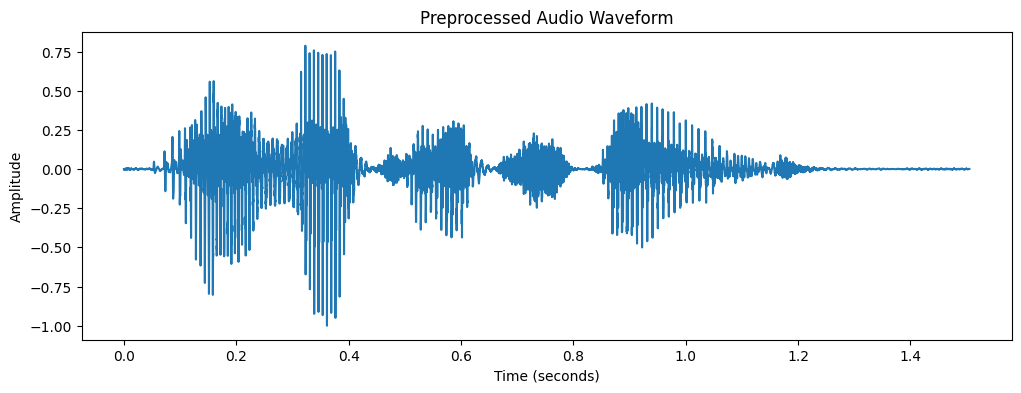

In [ ]:
time = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))
plt.plot(time, audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Preprocessed Audio Waveform")

plt.show()

In [ ]:
def preprocess_row(row):
    audio, sr = preprocess_audio(row["audio_path"])
    return audio, sr

audio, sr = preprocess_row(train.iloc[10])

print("File ID:", train.iloc[10]["file_id"])
print("Label:", train.iloc[10]["label"])
print("Duration:", len(audio) / sr)

File ID: DF_E_2411282
Label: bonafide
Duration: 4.5656875


In [ ]:
def preprocess_audio_safe(audio_path, target_sr=TARGET_SR):
    try:
        # Load as mono and resample to target sample rate
        audio, sr = librosa.load(
            audio_path,
            sr=target_sr,
            mono=True
        )

        # Convert to float32
        audio = audio.astype(np.float32)

        # Check for empty audio
        if len(audio) == 0:
            return None

        # Check for invalid values
        if np.isnan(audio).any() or np.isinf(audio).any():
            return None

        # Normalize amplitude
        max_amplitude = np.max(np.abs(audio))

        if max_amplitude > 0:
            audio = audio / max_amplitude

        return audio

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [ ]:
for i in range(5):

    path = train.iloc[i]["audio_path"]
    audio = preprocess_audio_safe(path)

    print(
        train.iloc[i]["file_id"],
        "|",
        train.iloc[i]["label"],
        "|",
        "Success" if audio is not None else "Failed"
    )

/tmp/ipykernel_1029/3521638027.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


DF_E_2015148 | spoof | Success
DF_E_2304773 | spoof | Success
DF_E_2362773 | spoof | Success


/tmp/ipykernel_1029/3521638027.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


DF_E_2159994 | bonafide | Success
DF_E_2276883 | bonafide | Success


In [ ]:
def check_audio_files(df, name):

    missing = 0
    failed = 0

    for path in df["audio_path"]:

        if not os.path.exists(path):
            missing += 1
            continue

        try:
            audio, sr = librosa.load(
                path,
                sr=TARGET_SR,
                mono=True
            )

            if len(audio) == 0:
                failed += 1

        except Exception:
            failed += 1

    print(f"{name}:")
    print("Total:", len(df))
    print("Missing:", missing)
    print("Failed to read:", failed)

#**MFCC + SVM**

#**LFCC + SVM**

Preprocessing → LFCC Extraction → Feature Preparation → SVM → Tuning → Evaluation → Save Results

## Step 1: LFCC Feature Extraction

First, we extract **Linear Frequency Cepstral Coefficients (LFCCs)** from the preprocessed speech signals.

LFCCs are features that describe the important characteristics of speech as numbers. These features will be used as input for the **SVM classifier**.

Unlike **MFCCs**, which use a **Mel-scaled filter bank**, LFCCs use a **linear filter bank**.

The LFCC extraction process includes:

1. **STFT:** "Short-Time Fourier Transform" Divide the speech signal into small frames and analyze the frequencies.
2. **Power Spectrum:** Calculate the power of the frequencies.
3. **Linear Filter Bank:** Apply filters that are evenly spaced in frequency.
4. **Logarithm:** Calculate the logarithm of the filter-bank energies.
5. **DCT:** Apply the Discrete Cosine Transform to get the cepstral coefficients.
6. **Select LFCCs:** Select the required number of LFCC coefficients.

Finally, the LFCC features are converted into a **fixed-size representation** so they can be used by the **SVM classifier**.


In [ ]:
import numpy as np
import librosa
import scipy.fftpack
import matplotlib.pyplot as plt

N_LFCC = 13
N_FFT = 512
HOP_LENGTH = 256
N_FILTERS = 40

### 1.1 Create a Linear Filter Bank

LFCCs use a **Linear Filter Bank** to analyze the frequencies in the speech signal.

The filter bank contains several **triangular filters**. Each filter looks at a specific range of frequencies and measures the **energy** in that range.

In our project, we use **40 filters**. The filters are evenly spaced from **0 Hz** to the **Nyquist frequency**, which is half of the sampling rate.

The filters also **overlap** with each other.


In [ ]:
def linear_filter_bank(
    sr,
    n_fft,
    n_filters,
    fmin=0,
    fmax=None
):
    if fmax is None:
        fmax = sr / 2

    # Frequency bins produced by the FFT
    freqs = np.linspace(
        0,
        sr / 2,
        n_fft // 2 + 1
    )

    # Linearly spaced filter points
    filter_points = np.linspace(
        fmin,
        fmax,
        n_filters + 2
    )

    # Initialize the filter bank
    filter_bank = np.zeros(
        (n_filters, len(freqs))
    )

    for i in range(n_filters):

        left = filter_points[i]
        center = filter_points[i + 1]
        right = filter_points[i + 2]

        # Rising part of the triangular filter
        left_slope = (freqs - left) / (center - left)

        # Falling part of the triangular filter
        right_slope = (right - freqs) / (right - center)

        # Construct the triangular filter
        filter_bank[i] = np.maximum(
            0,
            np.minimum(left_slope, right_slope)
        )

    return filter_bank